# Movie Genre Classification.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load the training data;
train = pd.read_csv(
    "train_data.txt",
    sep=":::",
    engine="python",
    names=["id", "title", "genre", "plot"]
)

In [3]:
train.head()

,id,title,genre,plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [4]:
train.shape

(54214, 4)

In [5]:
# value_counts check that how many genre are present. like drama 3 times, comedy 2 times.
train["genre"].value_counts()

genre
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult             590
crime             505
animation         498
sport             432
talk-show         391
fantasy           323
mystery           319
musical           277
biography         265
history           243
game-show         194
news              181
war               132
Name: count, dtype: int64

In [6]:
# check the missing value specially in the plot coloumns
train["plot"].isnull().sum()

np.int64(0)

In [7]:
# if any missing value get it then remove them by using dropna function. 
train = train.dropna(subset=["plot"])

In [8]:
train

,id,title,genre,plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...
...,...,...,...,...
54209,54210,"""Bonino"" (1953)",comedy,This short-lived NBC live sitcom centered on ...
54210,54211,Dead Girls Don't Cry (????),horror,The NEXT Generation of EXPLOITATION. The sist...
54211,54212,Ronald Goedemondt: Ze bestaan echt (2008),documentary,"Ze bestaan echt, is a stand-up comedy about g..."
54212,54213,Make Your Own Bed (1944),comedy,Walter and Vivian live in the country and hav...


In [9]:
# all the text converts into loweCase 
train["plot"] = train["plot"].str.lower()

In [10]:
# seprate input and output
X = train["plot"]
y = train["genre"]

In [11]:
# Spliting the data 80 : 20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42 )

In [12]:
# Convert test into numerical by using TF-IDF VECTORIZER.
tfidf = TfidfVectorizer( max_features = 50000, stop_words = "english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [13]:
# train the model
model = LinearSVC()
model.fit(X_train_tfidf, y_train) 

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [14]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5812966891081804


In [15]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

      action        0.43      0.32      0.36       263
       adult        0.74      0.43      0.54       112
   adventure        0.45      0.23      0.30       139
   animation        0.43      0.15      0.23       104
   biography        0.00      0.00      0.00        61
      comedy        0.53      0.59      0.56      1443
       crime        0.24      0.06      0.09       107
 documentary        0.69      0.81      0.74      2659
       drama        0.56      0.72      0.63      2697
      family        0.33      0.17      0.23       150
     fantasy        0.13      0.03      0.04        74
   game-show        0.81      0.62      0.70        40
     history        0.00      0.00      0.00        45
      horror        0.64      0.66      0.65       431
       music        0.59      0.56      0.58       144
     musical        0.20      0.02      0.04        50
     mystery        0.27      0.05      0.09        56
        n

In [16]:
#Now load the test data;
test = pd.read_csv(
    "test_data.txt",
    sep=":::",
    engine="python",
    names=["id", "title", "plot"]
)

In [17]:
# here we are replace NAN with " " space and if the upperCase exist then convert into lowerCase;
test["plot"] = test["plot"].fillna("").str.lower()

In [18]:
#again we convert  text into number of this dataset;
test_tfidf = tfidf.transform(test["plot"])

In [19]:
predictions = model.predict(test_tfidf)

In [20]:
# Add predictions to the test data.
test["predicted_genre"] = predictions

In [21]:
test[["title", "predicted_genre"]].head(10)

,title,predicted_genre
0,Edgar's Lunch (1998),comedy
1,La guerra de papá (1977),drama
2,Off the Beaten Track (2010),documentary
3,Meu Amigo Hindu (2015),drama
4,Er nu zhai (1955),drama
5,Riddle Room (2016),drama
6,L'amica (1969),drama
7,Ina Mina Dika (1989),comedy
8,Equinox Special: Britain's Tornados (2005),documentary
9,Press (2011),drama


In [22]:
#Save the predictions
test.to_csv("movie_genre_predictions.csv", index=False)

In [23]:
# load the actual solution file;
solution = pd.read_csv(
    "test_data_solution.txt",
    sep=":::",
    engine="python",
    names=["id", "title", "genre", "plot"]
)

In [24]:
#Compare our predictions with the actual genre
accuracy = accuracy_score(
    solution["genre"],
    test["predicted_genre"]
)

print("Final Accuracy:", accuracy)

Final Accuracy: 0.5772140221402214


In [25]:
# convert into percentage vlaue;
print("Final Accuracy:", round(accuracy * 100, 2), "%")

Final Accuracy: 57.72 %


# Now Comparing with 3 Models

### 1st Model : Naive Bayes;

In [26]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.45789910541363094


### 2nd Model: Logistic Regression;

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.5822189430969289


### 3rd Model: SVM ( Support Vector Machine ) 

In [28]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.5812966891081804


## comparing all three model together:

In [29]:
print("Naive Bayes:", accuracy_score(y_test, nb_pred))
print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

Naive Bayes: 0.45789910541363094
Logistic Regression: 0.5822189430969289
SVM: 0.5812966891081804


In [30]:
# predict test movies;
test["predicted_genre"] = lr.predict(test_tfidf)

In [31]:
# check predictions
test[["title", "predicted_genre"]].head(20)

,title,predicted_genre
0,Edgar's Lunch (1998),comedy
1,La guerra de papá (1977),drama
2,Off the Beaten Track (2010),documentary
3,Meu Amigo Hindu (2015),drama
4,Er nu zhai (1955),drama
5,Riddle Room (2016),drama
6,L'amica (1969),drama
7,Ina Mina Dika (1989),comedy
8,Equinox Special: Britain's Tornados (2005),documentary
9,Press (2011),drama


In [32]:
# calculate final accuracy:

final_accuracy = accuracy_score(
    solution["genre"],
    test["predicted_genre"]
)

print("Final Accuracy:", round(final_accuracy * 100, 2), "%")


Final Accuracy: 58.13 %


In [33]:
print(classification_report(
    solution["genre"],
    test["predicted_genre"],
    zero_division=0
))

               precision    recall  f1-score   support

      action        0.54      0.24      0.33      1314
       adult        0.65      0.18      0.28       590
   adventure        0.72      0.15      0.26       775
   animation        0.57      0.02      0.03       498
   biography        0.00      0.00      0.00       264
      comedy        0.54      0.58      0.56      7446
       crime        0.62      0.02      0.04       505
 documentary        0.65      0.87      0.75     13096
       drama        0.53      0.80      0.64     13612
      family        0.53      0.06      0.11       783
     fantasy        0.00      0.00      0.00       322
   game-show        0.93      0.46      0.62       193
     history        0.00      0.00      0.00       243
      horror        0.67      0.55      0.60      2204
       music        0.70      0.38      0.49       731
     musical        1.00      0.01      0.01       276
     mystery        0.00      0.00      0.00       318
        n

# Model Accuracy Comparison Graph;

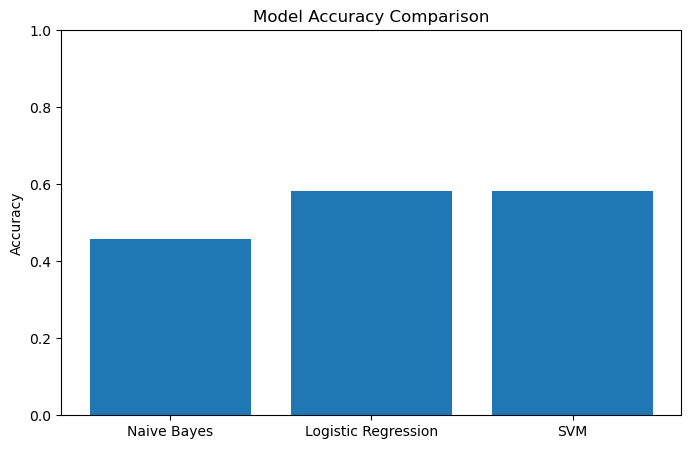

In [34]:
models = ["Naive Bayes", "Logistic Regression", "SVM"]
accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

# Confusion Matrix:

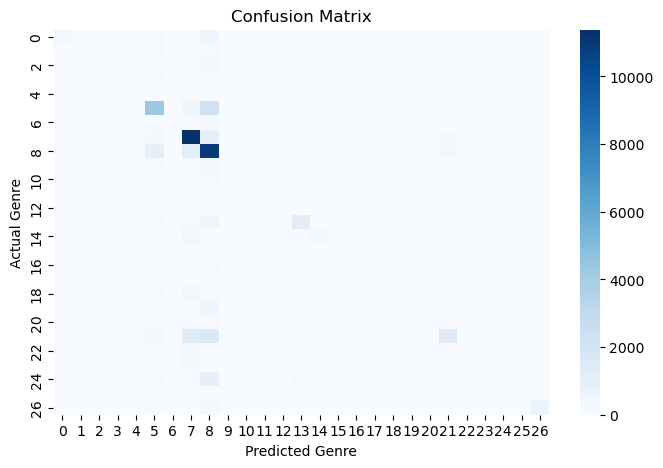

In [35]:
cm = confusion_matrix(
    solution["genre"],
    test["predicted_genre"]
)

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=False, cmap="Blues")

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix")

plt.show()

In [36]:
def story_type(movie_plot):
    movie_tfidf = tfidf.transform([movie_plot.lower()])
    prediction = lr.predict(movie_tfidf)
    return prediction[0]

# Now finally test the model:

In [37]:
xyz = "A group of friends enter a haunted house and try to survive the night."

story_type(xyz)

' horror '

In [38]:
Happy = "I love you and we are going on a romantic journey together."

print("Predicted Genre:", story_type(Happy))

Predicted Genre:  romance 


In [39]:
gandhi = "I am writing this letter to tell you how much you inspire me. You lived a simple life and always spoke the truth,You showed the world that we can win peace and freedom with non-violence and love"
story_type(gandhi)

' documentary '

In [40]:
xyz = """A young man moves to a new city.
He meets a mysterious girl and they become friends.
Soon, he discovers that she has a secret.
Together they try to solve the mystery."""
story_type(xyz)


' thriller '

# Conclusion

### The Movie Genre Classification project successfully predicts a movie's genre 
### from its plot summary using Natural Language Processing (NLP) and machine 
### learning.

### TF-IDF was used to convert movie plots into numerical features, and three 
### models—Naive Bayes, Logistic Regression, and SVM—were compared.
### Among them, Logistic Regression achieved the best validation accuracy of approximately 58.22%.

### The final model can predict the genre of new, unseen movie plots, making the system useful 
### for automatic movie genre classification. 